In [ ]:
# sentiment based review generator

from dotenv import load_dotenv
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


In [2]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
)

llm.invoke("hi").content

'Hello! How can I help you today?'

In [3]:
class SentimentReview(BaseModel):
    sentiment: str = Field(description = "The sentiment of the review, can be positive, negative or neutral")
    
class LLMState(TypedDict):
    sentiment: Literal["positive", "negative", "neutral"]
    review: str
    response: str

In [4]:
structured_llm = llm.with_structured_output(SentimentReview)

In [5]:
# Analyse the sentiment of review
def analyse_review_sentiment(state: LLMState):
    review = state["review"]
    prompt = f"Analyse the sentiment of the following review and return the sentiment as positive, negative or neutral: {review}"

    sentiment = structured_llm.invoke(prompt)
    return {"sentiment": sentiment}

# Generate response based on sentiment
def generate_positive_response(state: LLMState):
    review = state["review"]
    prompt = f"Generate a response for a positive review with the following review: {review}"

    response = llm.invoke(prompt)
    return {"response": response}

# Generate response based on sentiment
def generate_negative_response(state: LLMState):
    review = state["review"]
    prompt = f"Generate a response for a negative review with the following review: {review}"

    response = llm.invoke(prompt)
    return {"response": response}

# Generate response based on sentiment
def generate_neutral_response(state: LLMState):
    review = state["review"]
    prompt = f"Generate a response for a neutral review with the following review: {review}"
   
    response = llm.invoke(prompt)
    return {"response": response}

# Define the condition function to determine which response generation function to call based on sentiment
def sentiment_condition(state: LLMState) -> Literal["generate_positive_response", "generate_negative_response", "generate_neutral_response"]:
    sentiment = state["sentiment"]
    if sentiment == "positive":
        return "generate_positive_response"
    elif sentiment == "negative":
        return "generate_negative_response"
    else:
        return "generate_neutral_response"

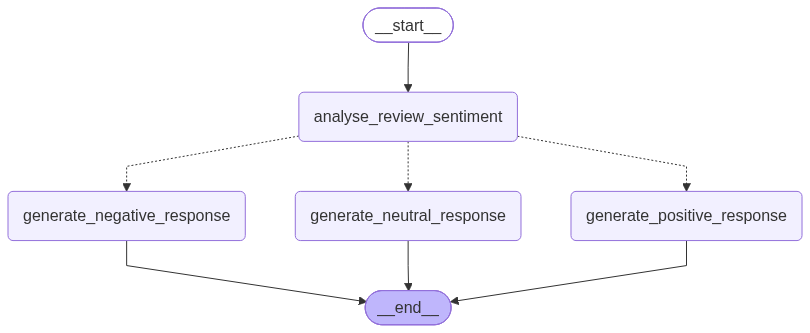

In [6]:
# intialize graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node("analyse_review_sentiment", analyse_review_sentiment)
graph.add_node("generate_positive_response", generate_positive_response)
graph.add_node("generate_negative_response", generate_negative_response)
graph.add_node("generate_neutral_response", generate_neutral_response)

# add edges
graph.add_edge(START, "analyse_review_sentiment")
graph.add_conditional_edges("analyse_review_sentiment", sentiment_condition)
graph.add_edge("generate_positive_response", END)
graph.add_edge("generate_negative_response", END)
graph.add_edge("generate_neutral_response", END)

# compile the graph into workflow
workflow = graph.compile()
workflow

In [7]:
review = "The product is amazing! I love it and would highly recommend it to anyone looking for a great experience."
result = workflow.invoke({"review": review})
result

{'sentiment': SentimentReview(sentiment='positive'),
 'review': 'The product is amazing! I love it and would highly recommend it to anyone looking for a great experience.',
 'response': AIMessage(content="Thank you for sharing your thoughts! We're delighted to hear that you had a great experience with the product and would recommend it to others. Your feedback is valuable to us, and we appreciate you taking the time to let us know. If you have any additional comments or suggestions, please feel free to reach out.", additional_kwargs={'reasoning_content': 'The user wants: "Generate a response for a neutral review with the following review: The product is amazing! I love it and would highly recommend it to anyone looking for a great experience."\n\nThey say "neutral review" but the review is positive. Perhaps they want a neutral tone response? Probably they want a response that acknowledges the review in a neutral way, maybe thanking them. So produce a response that thanks the reviewer, 